# IMT 574 Final Project Report:<br>Airbnb Rating Prediction and Feature Importance in Seattle
**Group Member: Anna Chi, Jimin Keel, Vivien Wang**

### 1. Describe the dataset you chose. 

We use Seattle’s Airbnb dataset from Inside Airbnb. 
The dataset contains information about Airbnb listings in Seattle, including host data, geographic information, listing characteristics, and review scores. Some example features include price, property_type, room_type, accommodates, availability, and review_scores_rating. <br>
The data was collected from public Airbnb listings through web scraping and published on the Inside Airbnb website as periodic snapshots. <br>
We chose this dataset because it provides rich information about listings and hosts, which allows us to analyze factors that may influence Airbnb ratings and listing performance.

### 2. Define a research question. 

#### Main Question: Which features are most important in predicting Airbnb listing rating scores?
To answer this question, we applied three supervised learning models, including `Random Forest`, `Gradient Boosting`, and `K-Nearest Neighbors (KNN)`, to predict Airbnb listing rating scores based on selected listing and host features. <br>
We then examined feature importance from the tree-based models to identify which factors contribute most to predicting rating scores.
#### Sub Question: Does the importance of these features differ across cities compared to overall Seattle?
To explore this question, we used `Random Forest` and `Gradient Boosting` models to compare feature importance across different cities. <br>
We selected 11 main neighborhoods in Seattle and analyzed whether the importance of the selected features varies across these areas.


### 3. Why is this algorithm a good way of answering your research question? 

We chose `Random Forest` as our main algorithm because it achieved the highest accuracy among the models we tested. <br>
Random Forest is also useful for our research question because it provides feature importance scores, which help us identify which variables are most important in predicting Airbnb listing rating scores. <br>
In addition, Random Forest can capture nonlinear relationships and interactions between features, which are common in real-world datasets like Airbnb listings. Therefore, it is a suitable model for both prediction and understanding feature importance.

### 4. Using the data you chose and the algorithm you chose, read in your data and run your model.

#### Data Processing

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions 
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
seattle = pd.read_csv("listings.csv.gz")

In [5]:
# turn price into float
seattle["price"] = (
    seattle["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [6]:
# filter price <= 0
seattle = seattle[seattle["price"] > 0]
# remove extreme price
p99_seattle = seattle["price"].quantile(0.99)
seattle = seattle[seattle["price"] <= p99_seattle]

In [7]:
# remove extreme value
p99_bedroom = seattle["bedrooms"].quantile(0.99)
p99_beds = seattle["beds"].quantile(0.99)
p99_bathroom = seattle["bathrooms"].quantile(0.99)
p99_accomodates = seattle["accommodates"].quantile(0.99)
seattle = seattle[seattle["bedrooms"] <= p99_bedroom]
seattle = seattle[seattle["beds"] <= p99_beds]
seattle = seattle[seattle["bathrooms"] <= p99_bathroom]
seattle = seattle[seattle["accommodates"] <= p99_accomodates]
seattle.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,...,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,...,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
3,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",NaN,NaN,https://a0.muscache.com/pictures/682034/54bc27...,14942,...,4.72,4.86,4.74,str-opli-19-002622,f,3,3,0,0,0.51
4,25002,https://www.airbnb.com/rooms/25002,20250925032813,2025-09-25,city scrape,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,https://a0.muscache.com/pictures/491561/cf5270...,102684,...,4.98,4.90,4.90,STR-OPLI-19-002617,t,1,1,0,0,6.06
5,26795,https://www.airbnb.com/rooms/26795,20250925032813,2025-09-25,city scrape,Lake Union Cottage - Shore and City View,"This sunny, corner lot is directly across from...",This area of the Eastlake Neighborhood is quie...,https://a0.muscache.com/pictures/179416/54927c...,114228,...,4.58,4.83,4.36,NaN,f,1,1,0,0,0.35


In [8]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
seattle["avg_price_group"] = seattle.groupby(group_cols)["price"].transform("mean")
seattle["relative_price"] = seattle["price"] / seattle["avg_price_group"]

In [9]:
# host response time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

seattle['host_response_time'] = seattle['host_response_time'].map(mapping_host_response_time)

In [10]:
# is_long_term
## minimum nights -> short-term listing vs. long-term listing
seattle['is_long_term'] = (seattle["minimum_nights"] > 7).astype(int)

In [11]:
# recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
seattle['recent_Review_proportion'] = seattle['number_of_reviews_ltm'] / seattle['number_of_reviews']

In [12]:
features = [
    "neighbourhood_group_cleansed",
    "review_scores_rating",
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "room_type",
    "is_long_term",
    # host characteristics
    "host_response_time",
    "host_identity_verified", 
    # others
    "number_of_reviews",
    "recent_Review_proportion",
    "estimated_occupancy_l365d"
]

In [13]:
seattle = seattle[features] 

In [14]:
seattle = seattle.dropna()
seattle.shape

(4863, 14)

In [15]:
%cd imt574_ml_final_project

/Users/peiyingw/imt574_ml_final_project


In [16]:
# turning pandas to csv 
seattle.to_csv('seattle_filtered.csv', index=False)

#### RQ1: Which features are most important in predicting Airbnb listing rating scores?

##### Features (Fixed)
For this question, we use these features as our variables to calculate the prediction of rating scores: 
1) Relative Pricing	
- (price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2) Housing Characteristics:
- Room Type 
- num of Bedrooms
- num of Bathrooms
- num of Beds
- num of Accommodates
- Is_Long_term: 1 if minimum_nights > 7, 0 if minimum_nights <= 7
3) Host Characteristics:
- Host_Response TIme
- Host_Identity_Verified
4) Other Users Experience/Engagement:
- number_of_reviews (TBD vvn: check the colinearity btw scoring and num of review)
- recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
- estimated_occupancy_l365d

For this section, we use three models to test the accuracy of prediction

##### Random Forest

In [17]:
df_seattle = pd.read_csv('seattle_filtered.csv')

In [19]:
## run RF model

X = df_seattle.drop(columns=["review_scores_rating"])
y = (df_seattle["review_scores_rating"] >= 4.9).astype(int)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
for n in [50, 100, 200, 300, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    print(f"n_estimators={n}: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

n_estimators=50: 0.6454
n_estimators=100: 0.6341
n_estimators=200: 0.6485
n_estimators=300: 0.6434
n_estimators=500: 0.6331


In [22]:
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [25]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.645426515930113
[[299 177]
 [168 329]]
              precision    recall  f1-score   support

           0       0.64      0.63      0.63       476
           1       0.65      0.66      0.66       497

    accuracy                           0.65       973
   macro avg       0.65      0.65      0.65       973
weighted avg       0.65      0.65      0.65       973



##### Gradient Boosting

In [27]:
## run GBDT model

X = df_seattle.drop(columns=["review_scores_rating"])
y = (df_seattle["review_scores_rating"] >= 4.9).astype(int)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
for lr in [0.01, 0.05, 0.1, 0.2, 0.5]:
    gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=200, random_state=42)
    gb.fit(X_train, y_train)
    print(f"learning_rate={lr}: {accuracy_score(y_test, gb.predict(X_test)):.4f}")

learning_rate=0.01: 0.6218
learning_rate=0.05: 0.6547
learning_rate=0.1: 0.6567
learning_rate=0.2: 0.6536
learning_rate=0.5: 0.6125


In [31]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.2,
    max_depth=3,
    subsample=1.0,
    random_state=42
)

gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [33]:
y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6536485097636177
[[293 183]
 [154 343]]
              precision    recall  f1-score   support

           0       0.66      0.62      0.63       476
           1       0.65      0.69      0.67       497

    accuracy                           0.65       973
   macro avg       0.65      0.65      0.65       973
weighted avg       0.65      0.65      0.65       973



##### KNN

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
for k in range(3, 20, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    print(f"k={k}: {accuracy_score(y_test, knn.predict(X_test_scaled)):.4f}")

k=3: 0.6012
k=5: 0.6033
k=7: 0.6187
k=9: 0.6095
k=11: 0.6084
k=13: 0.6146
k=15: 0.6105
k=17: 0.6043
k=19: 0.6084


In [36]:
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",13
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [37]:
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6145940390544707
[[269 207]
 [168 329]]
              precision    recall  f1-score   support

           0       0.62      0.57      0.59       476
           1       0.61      0.66      0.64       497

    accuracy                           0.61       973
   macro avg       0.61      0.61      0.61       973
weighted avg       0.61      0.61      0.61       973



**Based on the result above, we decided to use Gradient Boosting as our main algorithm since it has the highest accuracy among these three models.**

##### Feature importance using Gradient Boosting (GB)

In [38]:
importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

relative_price                                      0.236427
number_of_reviews                                   0.156403
recent_Review_proportion                            0.146363
estimated_occupancy_l365d                           0.066105
bathrooms                                           0.057803
neighbourhood_group_cleansed_Downtown               0.050389
room_type_Private room                              0.047414
bedrooms                                            0.036686
accommodates                                        0.035826
host_response_time                                  0.022722
neighbourhood_group_cleansed_University District    0.018937
beds                                                0.017392
neighbourhood_group_cleansed_Other neighborhoods    0.014605
neighbourhood_group_cleansed_West Seattle           0.013110
is_long_term                                        0.012467
dtype: float64

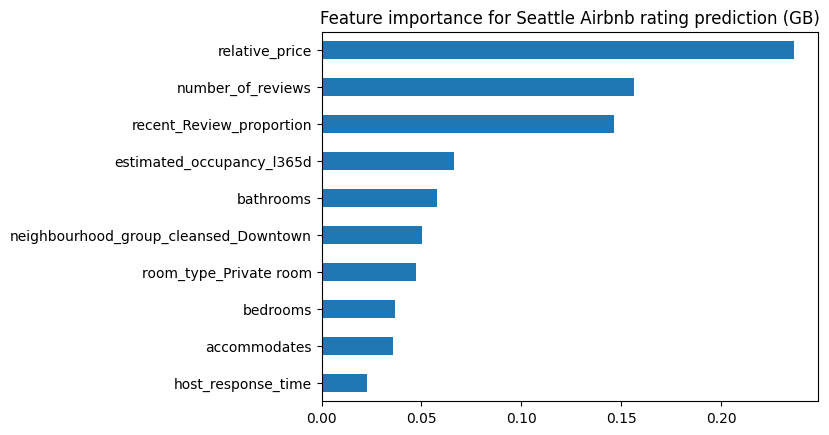

In [39]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature importance for Seattle Airbnb rating prediction (GB)")
plt.show()

#### TODO

#### RQ2: Does the importance of these features differ across cities compared to Seattle?

Based on the accuracy result above, we use `Gradient Boosting` as our model to do the features importance across cities compared to overall Seattle.

In [40]:
def run_gb_by_area(df, area_name, target_col="review_scores_rating", min_rows=30,
                   test_size=0.2, random_state=42, plot_top_n=10):
    df = df.dropna(subset=[target_col]).copy()

    if len(df) < min_rows:
        raise ValueError(f"{area_name}: Not enough rows ({len(df)})")

    # threshold
    thres = df[target_col].quantile(0.5)

    # X, y
    X = df.drop(columns=[target_col]).copy()
    y = (df[target_col] >= thres).astype(int)

    # one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    if y.nunique() < 2:
        raise ValueError(f"{area_name}: Only one class in target")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # model
    # rf = RandomForestClassifier(
    #     n_estimators=200,
    #     random_state=random_state
    # )
    # rf.fit(X_train, y_train)

    gb = GradientBoostingClassifier(
         learning_rate=0.2,
         n_estimators=200, 
         random_state=42)
    gb.fit(X_train, y_train)
    
    # prediction
    y_pred = gb.predict(X_test)

    # feature importance
    importance = pd.Series(
        gb.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_features = importance.head(plot_top_n)

    # results
    result = {
        "area": area_name,
        "threshold": thres,
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "feature_importance": importance,
        "top_features": top_features,
        "model": gb
    }

    return result

To decide the areas we want to research, we randomly pick 11 cities or rurals area as our target.

In [42]:
# area list
area_dfs = [
    "Downtown",
    "Central Area",
    "Queen Anne",
    "Beacon Hill",
    "Capitol Hill",
    "West Seattle",
    "Ballard",
    "Rainier Valley",
    "Cascade",
    "Northgate",
    "University District"]

all_results = {}

for i in range(len(area_dfs)):
    try:
        tmp = df_seattle[df_seattle['neighbourhood_group_cleansed'] == area_dfs[i]]
        tmp = tmp[features]
        result = run_gb_by_area(tmp, area_dfs[i])
        all_results[area_dfs[i]] = result
        print(f"\n=== {area_dfs[i]} ===")
        print("Threshold:", result["threshold"])
        print("Accuracy:", result["accuracy"])
        print("Confusion Matrix:\n", result["confusion_matrix"])
    except Exception as e:
        print(f"\n=== {area_dfs[i]} ===")
        print("Error:", e)


=== Downtown ===
Threshold: 4.85
Accuracy: 0.6055045871559633
Confusion Matrix:
 [[30 23]
 [20 36]]

=== Central Area ===
Threshold: 4.91
Accuracy: 0.4943820224719101
Confusion Matrix:
 [[17 27]
 [18 27]]

=== Queen Anne ===
Threshold: 4.91
Accuracy: 0.6
Confusion Matrix:
 [[22 14]
 [18 26]]

=== Beacon Hill ===
Threshold: 4.9
Accuracy: 0.47619047619047616
Confusion Matrix:
 [[ 7 13]
 [ 9 13]]

=== Capitol Hill ===
Threshold: 4.9
Accuracy: 0.6097560975609756
Confusion Matrix:
 [[18 23]
 [ 9 32]]

=== West Seattle ===
Threshold: 4.94
Accuracy: 0.44871794871794873
Confusion Matrix:
 [[18 17]
 [26 17]]

=== Ballard ===
Threshold: 4.95
Accuracy: 0.576271186440678
Confusion Matrix:
 [[17 12]
 [13 17]]

=== Rainier Valley ===
Threshold: 4.9
Accuracy: 0.5471698113207547
Confusion Matrix:
 [[17  9]
 [15 12]]

=== Cascade ===
Threshold: 4.87
Accuracy: 0.64
Confusion Matrix:
 [[ 6  6]
 [ 3 10]]

=== Northgate ===
Threshold: 4.84
Accuracy: 0.5454545454545454
Confusion Matrix:
 [[9 7]
 [8 9]]

==

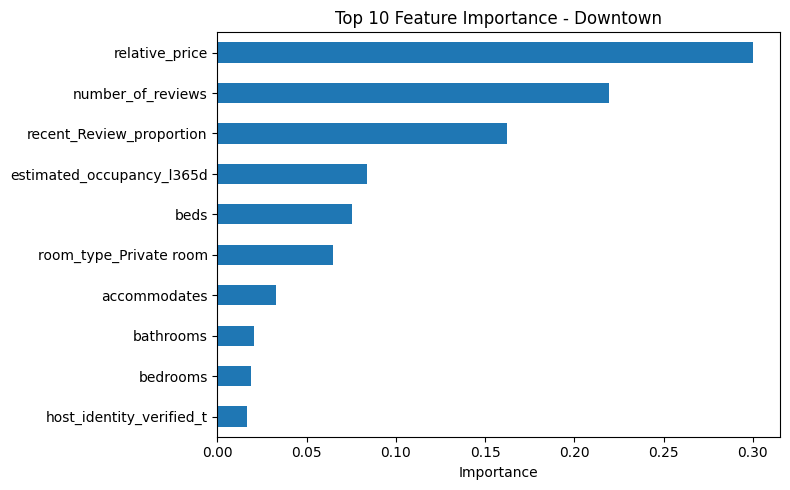

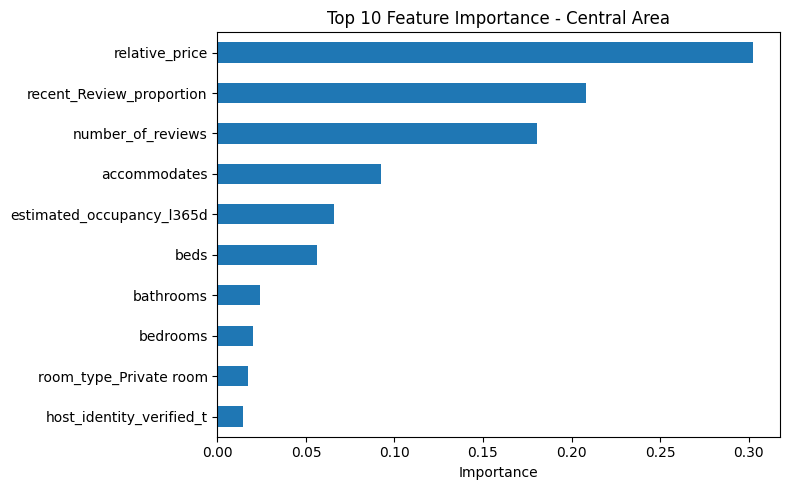

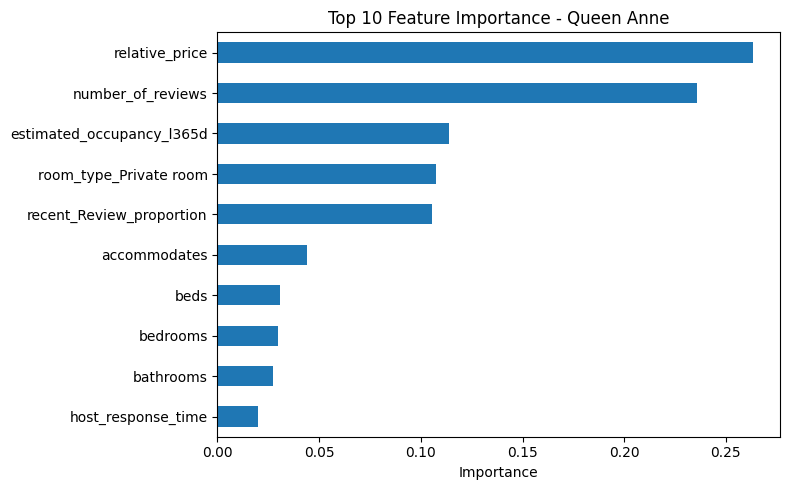

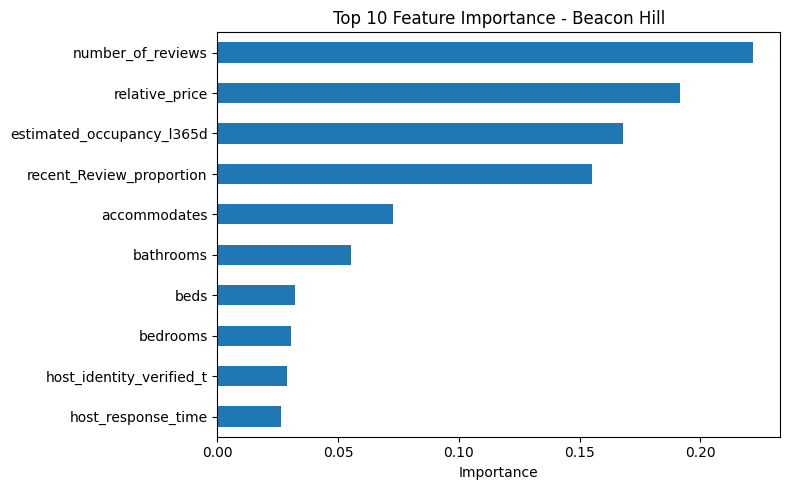

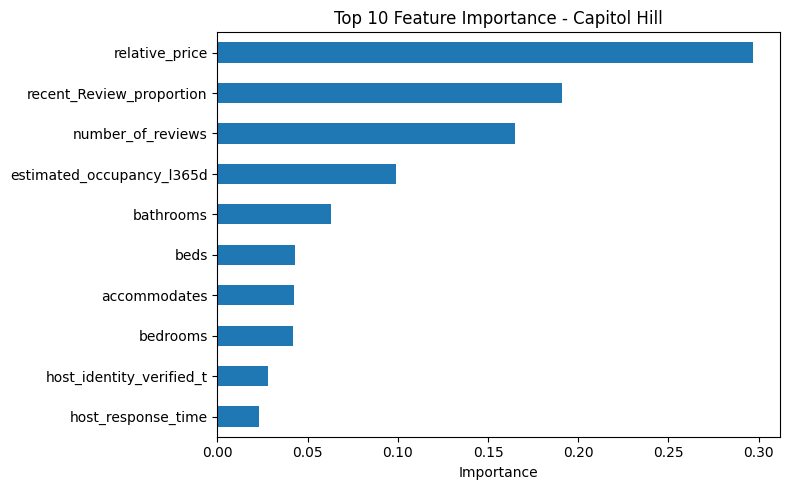

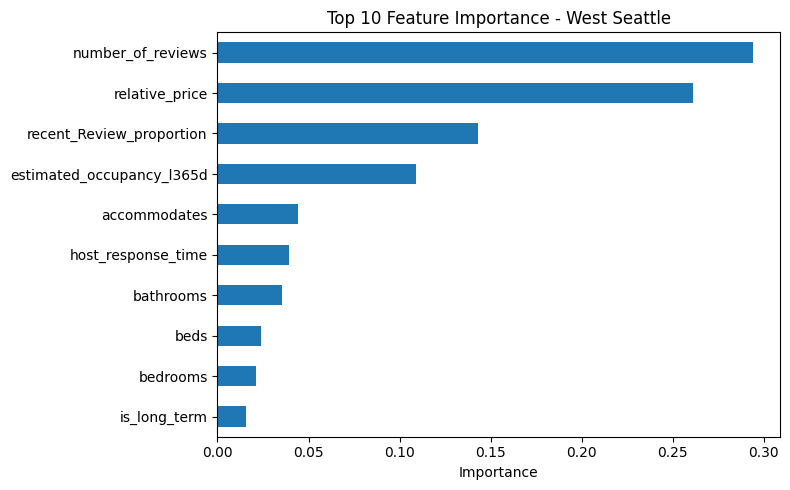

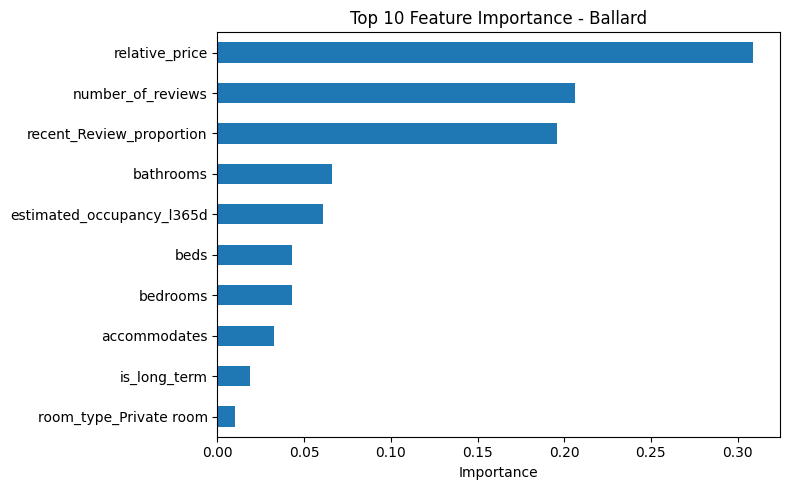

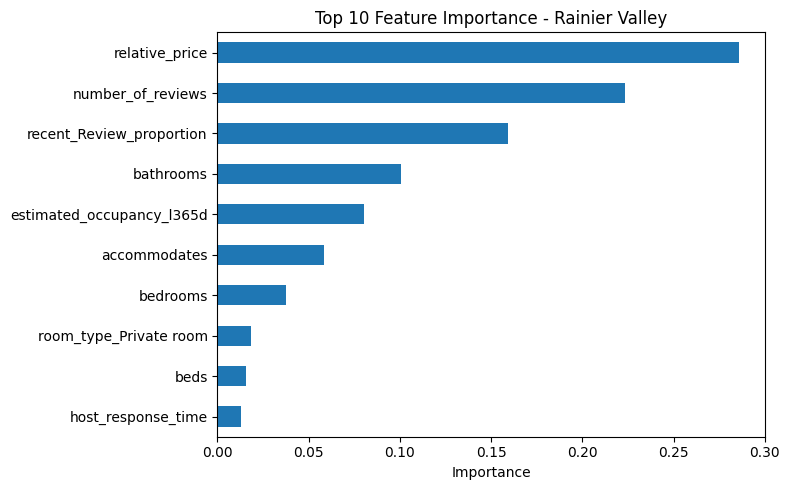

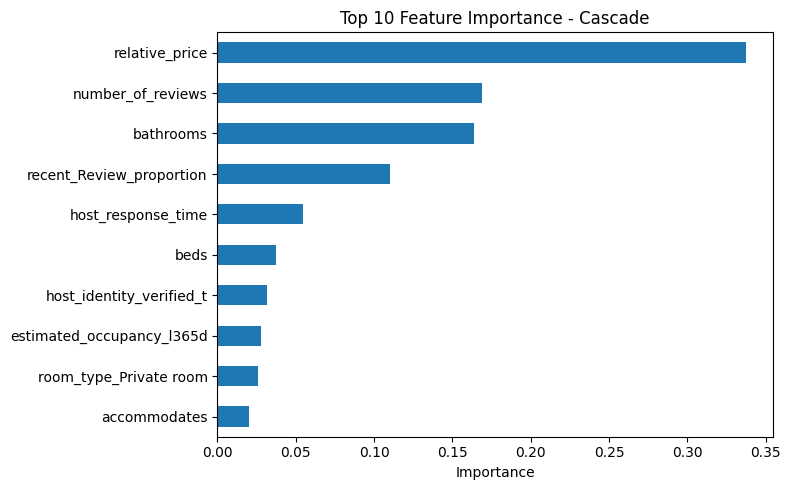

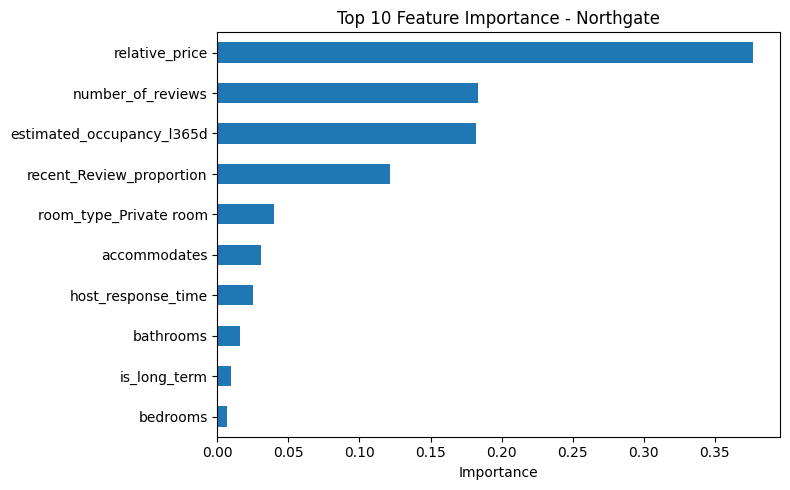

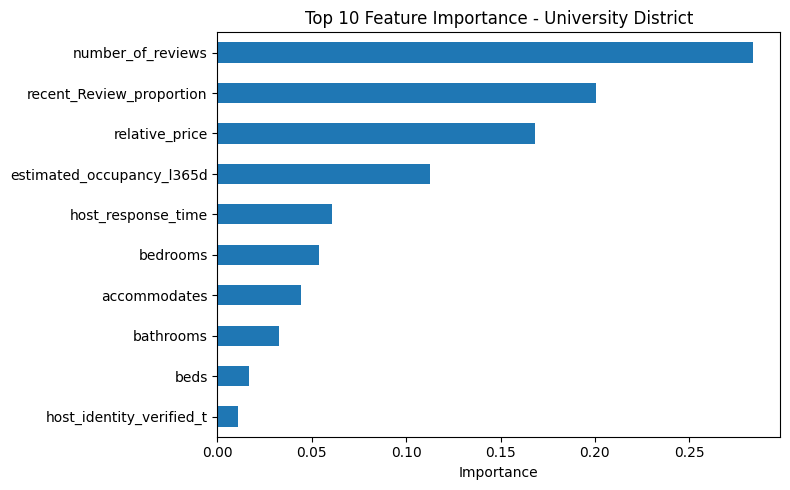

In [43]:
for area_name, result in all_results.items():
    plt.figure(figsize=(8, 5))
    result["top_features"].sort_values(ascending=True).plot(kind="barh")
    plt.title(f"Top 10 Feature Importance - {area_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

#### TODO

### 5. Conduct a hyperparameter sensitivity analysis by systematically varying key model parameters and measuring their impact on model performance.

We conducted hyperparameter sensitivity analysis across three models:
- **KNN**
    - n_neighbors Varied k from 3 to 19. Accuracy steadily increased up to k=13 (0.6308) and declined after, suggesting k=13 as optimal. Small k values caused overfitting, while large k values oversmoothed decision boundaries.
- **Random Forest**
    - n_estimators Varied from 50 to 500. Contrary to typical expectations, performance peaked at n_estimators=50 (0.6390) and gradually decreased with more trees, suggesting the additional trees introduced noise rather than improving generalization.
- **Gradient Boosting**
    - learning_rate Varied from 0.01 to 0.5. Performance peaked at learning_rate=0.2 (0.6554). Very low rates (0.01) underfit due to insufficient weight updates, while too high a rate (0.5) caused overshooting and degraded performance.

### 6. Report the evaluation of your model. 

We evaluated all four models using Accuracy on a binary classification task predicting whether an Airbnb listing receives a high or low review score.
For KNN, we varied k from 3 to 19. Accuracy steadily improved from 0.5867 at k=3 to a peak of 0.6308 at k=13, then declined. This indicates that too small a k leads to overfitting, while too large a k oversmooths the decision boundary.

For Random Forest, we varied n_estimators from 50 to 500. Performance peaked at n_estimators=50 with an accuracy of 0.6390 and gradually decreased as more trees were added. This suggests that additional trees introduced noise rather than improving generalization on this dataset.

For GBM, we varied learning_rate from 0.01 to 0.5. Accuracy increased from 0.6369 at 0.01 to a peak of 0.6554 at learning_rate=0.2, then sharply dropped to 0.6246 at 0.5, indicating that too high a learning rate causes the model to overshoot optimal weights.

For Logistic Regression, we varied the regularization parameter C from 0.01 to 100. Accuracy rose from 0.6318 at C=0.01 to 0.6513 at C=10, where it converged with no further improvement at C=100. This shows that strong regularization underfits the data, while moderate regularization achieves optimal performance.

Overall, GBM with learning_rate=0.2 achieved the best accuracy of 65.54%, followed by Logistic Regression at 65.13%, Random Forest at 63.90%, and KNN at 63.08%. All models performed within a narrow range, suggesting that hyperparameter tuning provided modest but consistent improvements, and that the feature set itself is the primary limiting factor in predictive performance.

### 7. Create a visualization demonstrating your findings. 
- Make sure to include a title and axis labels.
- Describe what’s being shown in your visualization.
- **put our code / graph here!**

### 8. What challenges did you run into? 

One challenge we encountered early in the project was defining a clear and feasible research question. At first, we were interested in exploring Airbnb price differences between cities, states, or even countries. However, we quickly realized that the dataset lacked important variables needed for this type of analysis. For example, the dataset does not include booking date information, which makes it difficult to analyze seasonal pricing patterns. 

Additionally, comparing prices across different geographic areas introduces many complex factors such as local demand, tourism, cost of living, and regional regulations. These differences made cross-location price analysis too complicated to conduct accurately with the available data.

Because of these limitations, we adjusted our research focus. Instead of predicting price, we decided to predict Airbnb rating scores, which are one of the most important factors users consider when choosing a place to stay. Initially, we used regression models to predict the exact rating score, since ratings are continuous numerical values. However, the model performance was not strong, partly because Airbnb ratings tend to have very little variation and are heavily skewed toward high values. This makes it difficult for regression models to capture meaningful differences.

To address this issue, we reframed the task as a classification problem, predicting whether a listing has a high rating or low rating based on the median rating score as the threshold. This transformation simplified the prediction problem and improved model performance. We also carefully selected features and created some calculated variables while trying to avoid multicollinearity. 

Finally, we compared several models and selected Gradient Boosting Classifier as the best-performing model to analyze feature importance and compare results across different neighborhoods in Seattle.


### 9. Explain how your machine learning solution answers the research question you defined. 


Our research question focuses on predicting Airbnb rating outcomes and understanding which features influence ratings across different neighborhoods in Seattle. The machine learning approach answers this question by using listing characteristics—such as price, room type, host status, number of reviews, and accommodation capacity—to predict whether a listing will receive a high or low rating. After comparing multiple models, we found that the Gradient Boosting Classifier achieved the best performance. This model is especially effective because it builds trees sequentially and improves prediction errors step by step, allowing it to capture complex and nonlinear relationships in the data. It also provides feature importance scores, which help us identify which factors have the strongest influence on ratings in different neighborhoods.

One advantage of this approach is that it can uncover patterns that are not easily visible through simple statistical analysis. For example, it can show whether host-related factors (such as being a superhost) or listing characteristics (such as price or number of bedrooms) play a more important role in determining high ratings. When applied to unseen data, the model can help hosts understand which aspects of their listings may improve guest satisfaction and assist users in identifying listings that are more likely to receive high ratings.

However, there are also risks when applying this model to new data. If the model overfits the training data or if future Airbnb listings differ significantly from the current dataset, its predictions may become less accurate. Additionally, since Airbnb ratings tend to be highly skewed toward higher values, the model may struggle to distinguish subtle differences between listings. If the model makes incorrect predictions, it could mislead hosts into focusing on less important features or cause users to form inaccurate expectations about listing quality. On the other hand, when the model performs well, it can provide meaningful insights that help hosts improve their services and support users in making better booking decisions.

From a societal perspective, this model has both positive and negative impacts. On the positive side, it increases transparency by highlighting the key factors that contribute to higher ratings, which may encourage hosts to improve quality and consistency. It can also make the booking process more efficient for users. However, there are potential downsides. The model may unintentionally reinforce existing inequalities, such as favoring certain neighborhoods, property types, or hosts with more resources. Additionally, over-reliance on model predictions could reduce the importance of personal experience and qualitative factors in hospitality.


### 10. Name one research question you might ask next for future work 

This question is important because price is one of the most visible factors in the Airbnb marketplace. While our current model includes price as a feature, it does not fully analyze how different price levels influence guest satisfaction or perceived value. Investigating this relationship could help hosts balance profitability and customer satisfaction, and it could also provide insights into how guests evaluate value when booking accommodations. Understanding this relationship would further improve both pricing strategies and recommendation systems for Airbnb listings.

### Model Card